In [1]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import pandas as pd

In [2]:
# Load your .mat file
data = sio.loadmat('./Results/Results_getRxnsCount.mat')
single_lp = data['single_lp'].flatten()
single_milp = data['single_milp'].flatten()
comm_lp = data['comm_lp'].flatten()
comm_milp = data['comm_milp'].flatten()

C:\Users\Admin\AppData\Local\Temp\ipykernel_39004\3279341979.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=40)


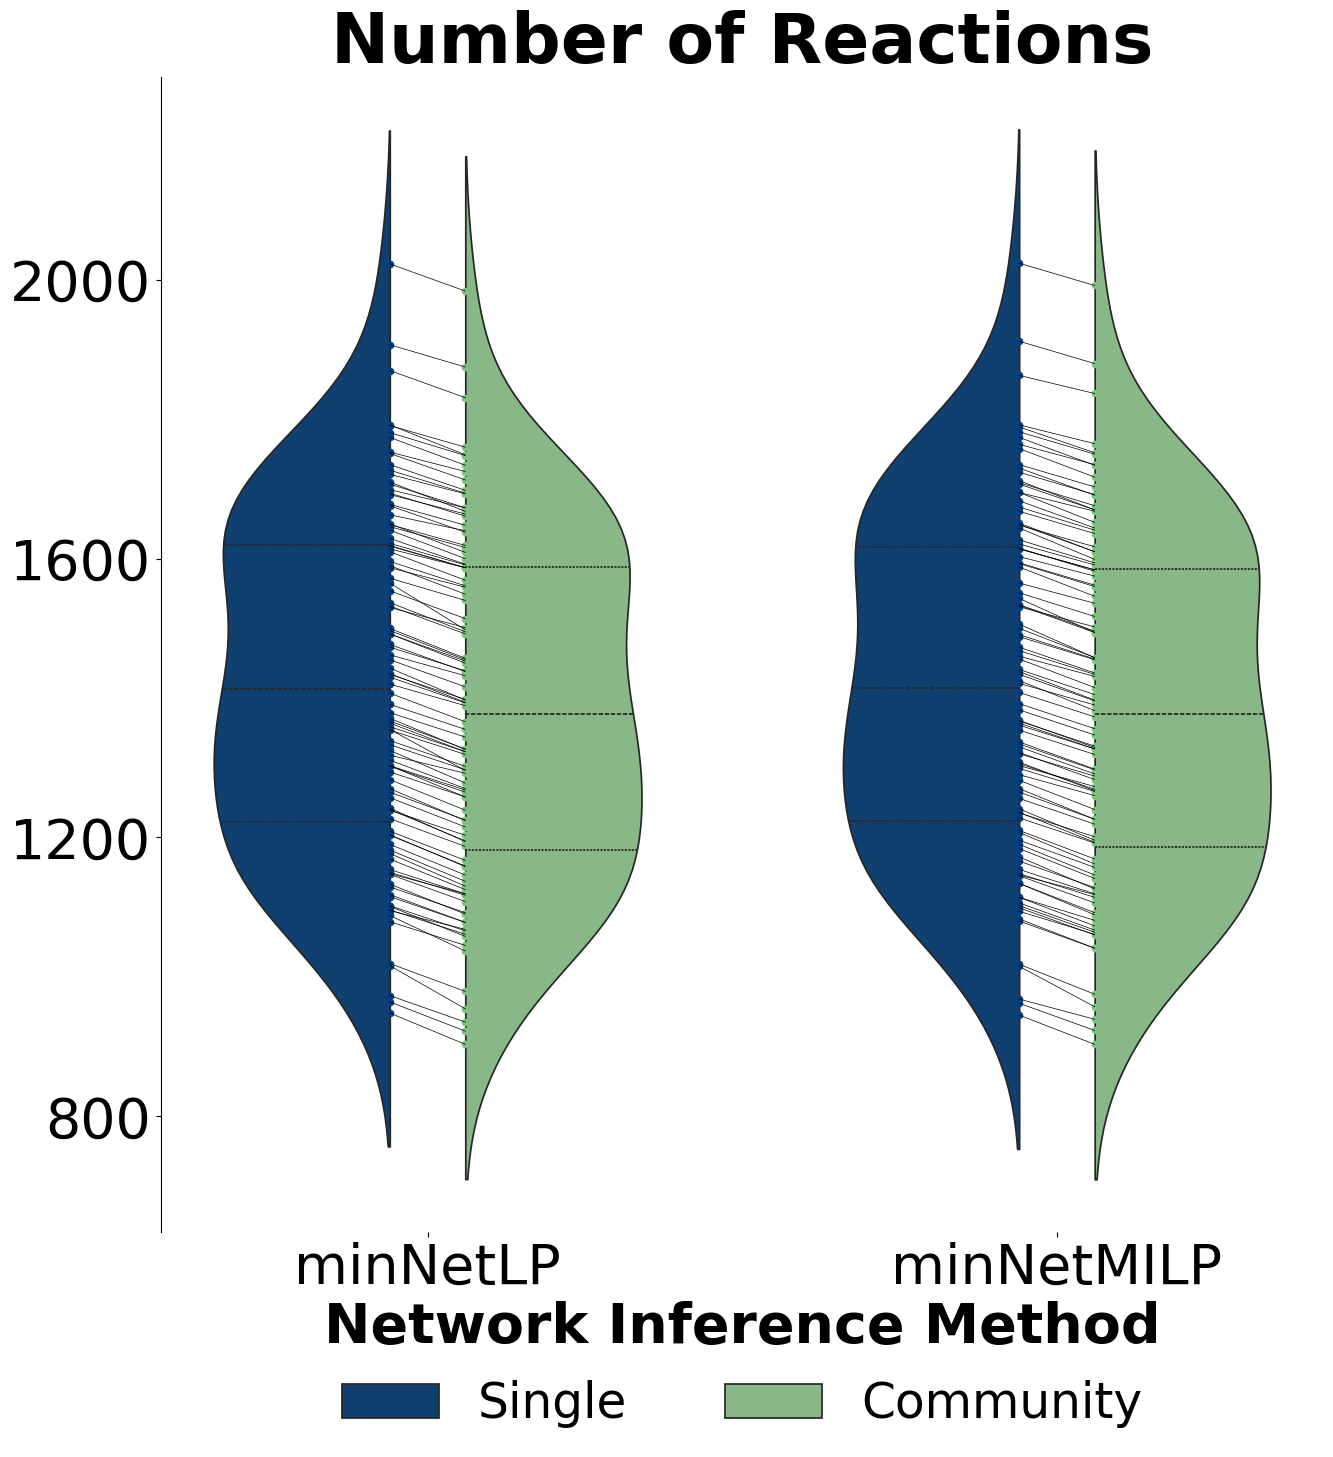

In [3]:
fig, ax = plt.subplots(1,1,figsize=(15,15))
# generating a dataframe for the data
data = {
    'Model': list(range(1, len(single_lp) + 1)) * 4,
    'Number of Reactions': single_lp.tolist() + single_milp.tolist() + comm_lp.tolist() + comm_milp.tolist(),
    'GapFillType': ['Single'] * len(single_lp) + ['Single'] * len(single_milp) + ['Community'] * len(comm_lp) + ['Community'] * len(comm_milp),
    'Method': ['minNetLP'] * len(single_lp) + ['minNetMILP'] * len(single_milp) + ['minNetLP'] * len(comm_lp) + ['minNetMILP'] * len(comm_milp)
}
df = pd.DataFrame(data)
pal={'Single':'#004080','Community':'#80c080'}
yticks=np.arange(800, 2400, 400)
metric ='Number of Reactions'


sns.violinplot(y=metric,x = 'Method',hue='GapFillType',split=True,gap=0.3,data=df,ax=ax,inner="quart",palette=pal)
ax.set_title(metric,fontsize=50,fontweight='bold')
# making the spines off
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylabel('',fontsize=1,fontweight='bold')

ax.set_xlabel('Network Inference Method',fontsize=40,fontweight='bold')

# making the ticlabels bold
ax.set_xticklabels(ax.get_xticklabels(),fontsize=40)
ax.set_yticks(yticks)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=40)

# getting the count of unique df['Model']
models = df['Model'].unique()

# getting the xticks location
xticks = [tick.get_position()[0] for tick in ax.get_xticklabels()]
# making a slope plot
scale = 0.06
count_of_higher = {'lp_single':0,'lp_community':0,'milp_single':0,'milp_community':0}
for m in models:
    df1 = df[(df['Model']==m)&(df['Method']=='minNetLP')]
    ax.scatter([xticks[0]-scale],df1[df1['GapFillType']=='Single'][metric],color=pal['Single'],s=20)
    ax.scatter([xticks[0]+scale],df1[df1['GapFillType']=='Community'][metric],color=pal['Community'],s=20)
    ax.plot([xticks[0]-0.06,xticks[0]+0.06],[df1[df1['GapFillType']=='Single'][metric],df1[df1['GapFillType']=='Community'][metric]],'-',color='k',linewidth=0.5)

    df2 = df[(df['Model']==m)&(df['Method']=='minNetMILP')]
    ax.scatter([xticks[1]-scale],df2[df2['GapFillType']=='Single'][metric],color=pal['Single'],s=20)
    ax.scatter([xticks[1]+scale],df2[df2['GapFillType']=='Community'][metric],color=pal['Community'],s=20)
    ax.plot([xticks[1]-0.06,xticks[1]+0.06],[df2[df2['GapFillType']=='Single'][metric],df2[df2['GapFillType']=='Community'][metric]],'-',color='k',linewidth=0.5)

    if df1[df1['GapFillType']=='Single'][metric].values < df1[df1['GapFillType']=='Community'][metric].values:
        count_of_higher['lp_community'] += 1
    else:
        count_of_higher['lp_single'] += 1
    if df2[df2['GapFillType']=='Single'][metric].values < df2[df2['GapFillType']=='Community'][metric].values:
        count_of_higher['milp_community'] += 1
    else:
        count_of_higher['milp_single'] += 1
ax.legend(fontsize=35,loc='upper center', bbox_to_anchor=(0.5, -0.09),
        ncol=2, frameon=False)
plt.savefig('./carvemeRxnsCount.png',bbox_inches='tight',dpi=300)

In [4]:
# running wilcoxon signed rank test
from scipy.stats import wilcoxon

print('For the case of minNetLP - Number of reactions')
res = wilcoxon(comm_lp.astype(np.float32), single_lp.astype(np.float32),  alternative='less')
print(res.pvalue)

print('For the case of minNetMILP - Number of reactions')
res = wilcoxon(comm_milp.astype(np.float32), single_milp.astype(np.float32), alternative='less')
print(res.pvalue)


For the case of minNetLP - Number of reactions
4.1539194797136807e-19
For the case of minNetMILP - Number of reactions
4.0341174618923296e-19
